# 02 — Feature Engineering

**Input:** `data/cs_clean.parquet`  
**Output:** `data/cs_features.parquet`

---

In [1]:
import os, warnings, pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')
%matplotlib inline

os.makedirs('data',    exist_ok=True)
os.makedirs('reports', exist_ok=True)

plt.rcParams.update({'figure.dpi':120,'axes.spines.top':False,'axes.spines.right':False,'axes.titlesize':13})
PAL  = {'good':'#1D9E75','bad':'#D85A30','neutral':'#378ADD'}
DLQ  = ['past_due_30_59','past_due_60_89','times_90d_late']

df = pd.read_parquet('data/cs_clean.parquet')
print(f'Loaded: {df.shape[0]:,} rows x {df.shape[1]} cols')
print(f'Default rate: {df["default"].mean()*100:.2f}%')

Loaded: 149,999 rows x 12 cols
Default rate: 6.68%


## 1. WoE / IV Functions

In [2]:
def compute_woe_iv(df, feature, target, bins=10):
    temp = df[[feature, target]].copy().dropna()
    if temp[feature].nunique() > 10:
        try:
            temp['bin'] = pd.qcut(temp[feature], q=bins, duplicates='drop')
        except:
            temp['bin'] = pd.cut(temp[feature], bins=bins)
    else:
        temp['bin'] = temp[feature].astype(str)
    tot_e  = temp[target].sum()
    tot_ne = len(temp) - tot_e
    g = temp.groupby('bin', observed=True)[target].agg(['sum','count'])
    g.columns = ['events','total']
    g['nonevents']    = g['total'] - g['events']
    g['pct_e']        = g['events'].replace(0, 0.0001) / tot_e
    g['pct_ne']       = g['nonevents'].replace(0, 0.0001) / tot_ne
    g['woe']          = np.log(g['pct_e'] / g['pct_ne'])
    g['iv']           = (g['pct_e'] - g['pct_ne']) * g['woe']
    g['default_rate'] = g['events'] / g['total']
    return g.reset_index(), g['iv'].sum()

def iv_label(iv):
    if iv < 0.02: return 'Useless'
    if iv < 0.1:  return 'Weak'
    if iv < 0.3:  return 'Medium'
    if iv < 0.5:  return 'Strong'
    return 'Suspicious'

print('WoE/IV functions defined ✓')

WoE/IV functions defined ✓


## 2. Information Value — All Features

,feature,IV,strength
0,revolving_utilization,1.1134,Suspicious
1,past_due_30_59,0.4309,Strong
2,age,0.2592,Medium
3,monthly_income,0.1270,Medium
4,debt_ratio,0.0737,Weak
5,open_credit_lines,0.0669,Weak
6,dependents,0.0250,Weak
7,real_estate_loans,0.0121,Useless
8,times_90d_late,0.0000,Useless
9,past_due_60_89,0.0000,Useless


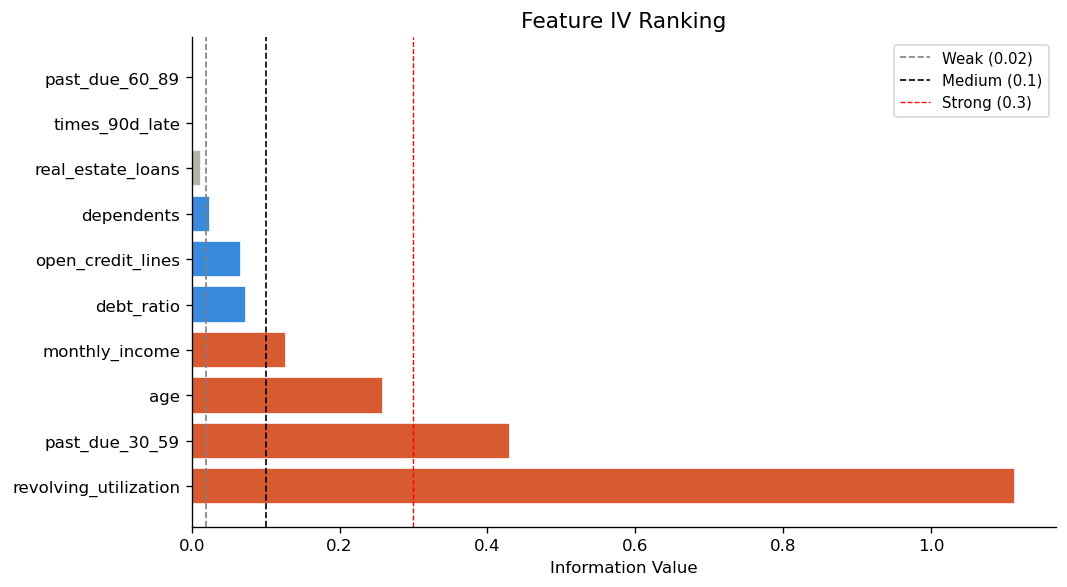

In [3]:
raw_feats  = [c for c in df.columns if c not in ['default','income_was_missing']]
iv_summary = []; woe_tables = {}

for feat in raw_feats:
    try:
        tbl, iv = compute_woe_iv(df, feat, 'default')
        woe_tables[feat] = tbl
        iv_summary.append({'feature':feat,'IV':iv,'strength':iv_label(iv)})
    except Exception as e:
        print(f'  Skipped {feat}: {e}')

iv_df = pd.DataFrame(iv_summary).sort_values('IV', ascending=False).reset_index(drop=True)
display(iv_df.style.format({'IV':'{:.4f}'}).bar(subset='IV', color=PAL['neutral']))

fig, ax = plt.subplots(figsize=(9,5))
colors = [PAL['bad'] if iv>=0.1 else PAL['neutral'] if iv>=0.02 else '#B4B2A9' for iv in iv_df['IV']]
ax.barh(iv_df['feature'], iv_df['IV'], color=colors, edgecolor='white')
ax.axvline(0.02, color='gray',  ls='--', lw=1, label='Weak (0.02)')
ax.axvline(0.1,  color='black', ls='--', lw=1, label='Medium (0.1)')
ax.axvline(0.3,  color='red',   ls='--', lw=0.8, label='Strong (0.3)')
ax.set_xlabel('Information Value'); ax.set_title('Feature IV Ranking'); ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('reports/iv_ranking.png', bbox_inches='tight')
plt.show()

## 3. WoE Charts

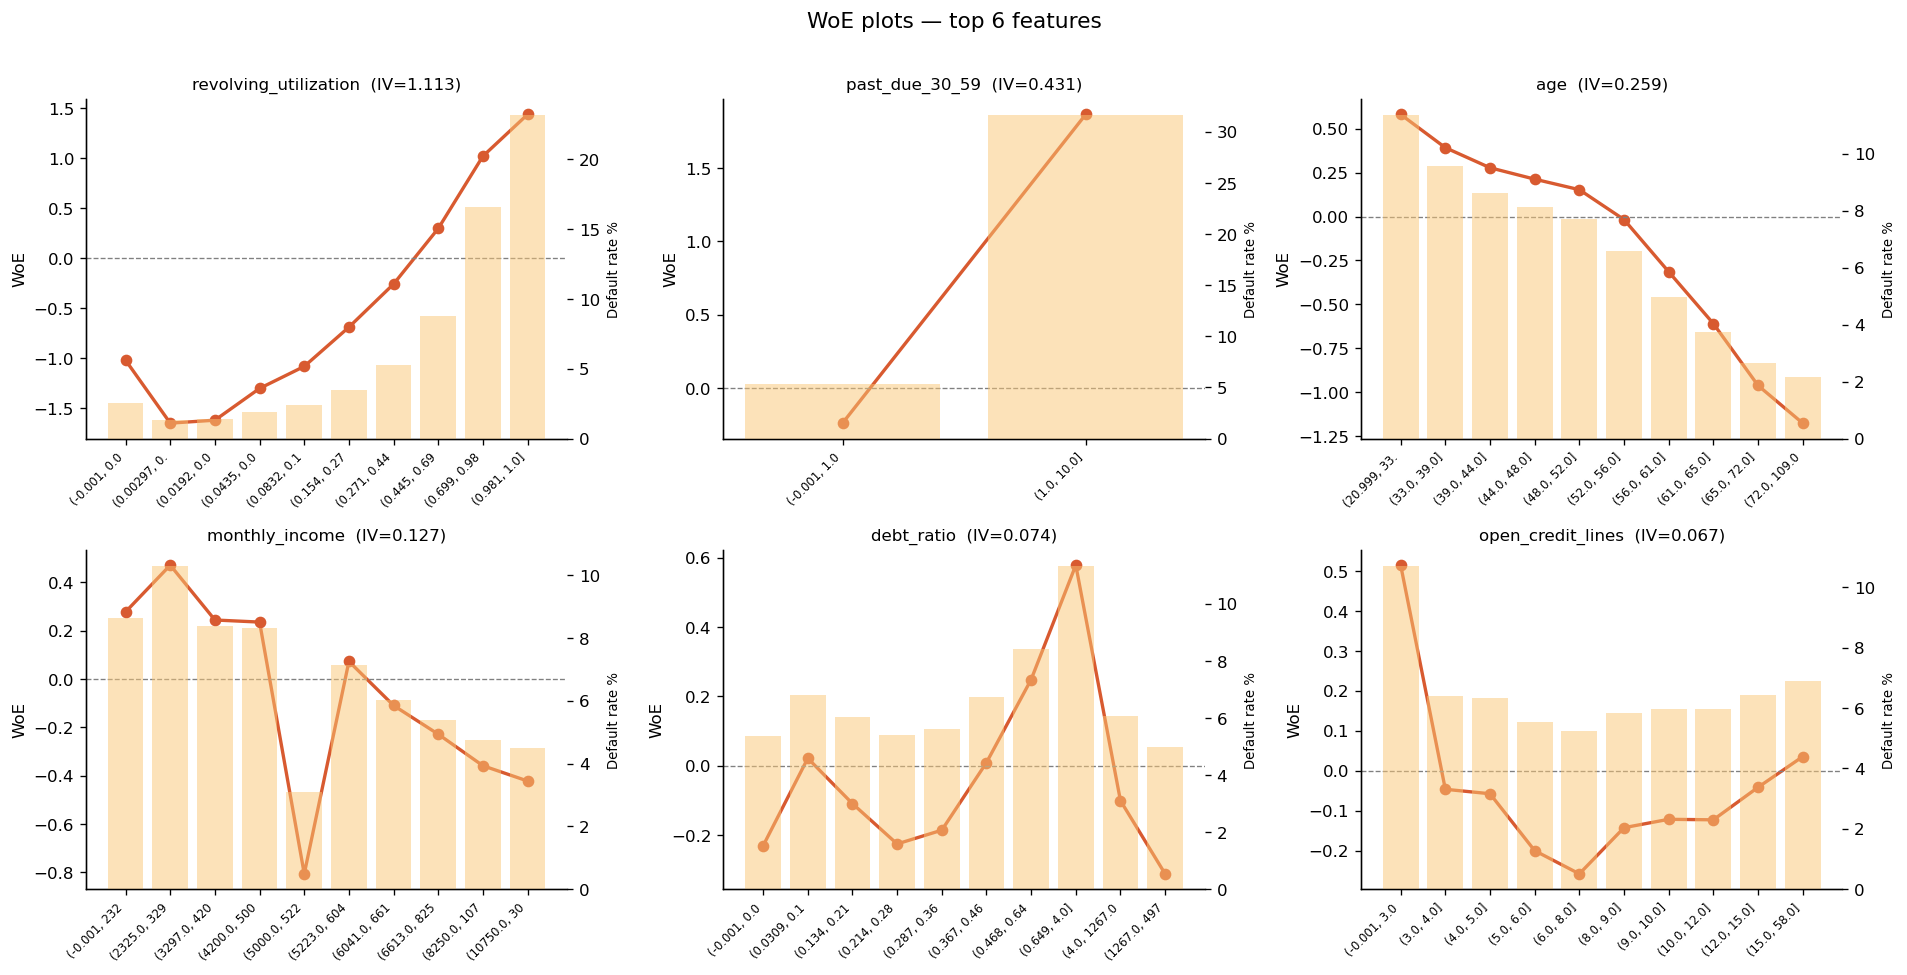

In [4]:
top6 = iv_df.head(6)['feature'].tolist()
fig, axes = plt.subplots(2,3,figsize=(16,8))
for ax, feat in zip(axes.flatten(), top6):
    tbl = woe_tables[feat].sort_values('bin'); x = range(len(tbl))
    ax2 = ax.twinx()
    ax2.bar(x, tbl['default_rate']*100, color='#FAC775', alpha=0.5)
    ax2.set_ylabel('Default rate %', fontsize=8)
    ax.plot(x, tbl['woe'], color=PAL['bad'], marker='o', lw=2, label='WoE')
    ax.axhline(0, color='gray', lw=0.8, ls='--')
    ax.set_xticks(x); ax.set_xticklabels([str(b)[:12] for b in tbl['bin']], rotation=45, ha='right', fontsize=7)
    iv_val = iv_df[iv_df['feature']==feat]['IV'].values[0]
    ax.set_title(f'{feat}  (IV={iv_val:.3f})', fontsize=10)
    ax.set_ylabel('WoE')
plt.suptitle('WoE plots — top 6 features', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('reports/woe_charts.png', bbox_inches='tight')
plt.show()

## 4. Feature Engineering

In [5]:
dfe = df.copy()

dfe['total_delinquencies']   = dfe['past_due_30_59'] + dfe['past_due_60_89'] + dfe['times_90d_late']
dfe['ever_seriously_delinq'] = (dfe['times_90d_late'] > 0).astype(int)
dfe['delinq_score']          = dfe['past_due_30_59']*1 + dfe['past_due_60_89']*2 + dfe['times_90d_late']*3
dfe['debt_to_income']        = dfe['debt_ratio'] * dfe['monthly_income']
dfe['income_per_dependent']  = dfe['monthly_income'] / (dfe['dependents'] + 1)
dfe['log_income']            = np.log1p(dfe['monthly_income'])
dfe['high_utilization']      = (dfe['revolving_utilization'] > 0.75).astype(int)
dfe['util_x_delinq']         = dfe['revolving_utilization'] * dfe['total_delinquencies']
dfe['age_sq']                = dfe['age'] ** 2
dfe['re_loan_pct']           = dfe['real_estate_loans'] / (dfe['open_credit_lines'] + 1)

ENG_FEATS = ['total_delinquencies','ever_seriously_delinq','delinq_score',
             'debt_to_income','income_per_dependent','log_income',
             'high_utilization','util_x_delinq','age_sq','re_loan_pct']

print(f'Engineered {len(ENG_FEATS)} new features:')
for f in ENG_FEATS: print(f'  {f}')

Engineered 10 new features:
  total_delinquencies
  ever_seriously_delinq
  delinq_score
  debt_to_income
  income_per_dependent
  log_income
  high_utilization
  util_x_delinq
  age_sq
  re_loan_pct


## 5. Select Features & Save

In [6]:
selected_raw = iv_df[iv_df['IV'] >= 0.02]['feature'].tolist()
print(f'Raw features selected (IV>=0.02): {len(selected_raw)}')

eng_iv = []
for feat in ENG_FEATS:
    try:
        _, iv = compute_woe_iv(dfe, feat, 'default')
        if iv >= 0.02: eng_iv.append(feat)
    except: pass
print(f'Engineered features selected:      {len(eng_iv)}')

ALL_FEATURES = list(dict.fromkeys(selected_raw + eng_iv + ['income_was_missing']))
print(f'Total features:                    {len(ALL_FEATURES)}')

df_features = dfe[['default'] + ALL_FEATURES].copy()
print(f'\nFeature matrix shape: {df_features.shape}')

df_features.to_parquet('data/cs_features.parquet', index=False)
iv_df.to_csv('reports/iv_summary.csv', index=False)
with open('data/woe_tables.pkl', 'wb') as f:
    pickle.dump(woe_tables, f)

print('Saved → data/cs_features.parquet ✓')
print('Saved → reports/iv_summary.csv ✓')
print('Saved → data/woe_tables.pkl ✓')
print('\n=== Notebook 02 complete — run 03_modelling.ipynb next ===')

Raw features selected (IV>=0.02): 7
Engineered features selected:      10
Total features:                    18

Feature matrix shape: (149999, 19)
Saved → data/cs_features.parquet ✓
Saved → reports/iv_summary.csv ✓
Saved → data/woe_tables.pkl ✓

=== Notebook 02 complete — run 03_modelling.ipynb next ===
